# Notebook 3 — Unbalanced-Growth Path (Phase 2)

This notebook solves the **full stochastic equilibrium** along the $u$-path via backward induction:

1. Solve the 6-equation nonlinear system at each date $t = T, T-1, \ldots, 1$
2. Recover the RoW domestic risk-free rate $R^W_f$ via the RoW domestic-bond FOC ($E_t[\mathcal{M}^*(R^W_f - R^*_p)] = 0$, V7)
3. Verify all market-clearing conditions ex post
4. Produce the 9-panel equilibrium plot

In [1]:
using Pkg; Pkg.activate(".")
include("TwoCountryOLG.jl")
using Plots, LaTeXStrings, Printf
gr()

  Activating 

project at `~/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes`


Plots.GRBackend()

In [2]:
p = ModelParams()
validate_params(p)
paths = generate_exogenous_paths(p)

# ── Phase 1: Solve reported balanced states with Assumption 7 (V7) switch-date scaling ──
# solve_u_path extends paths and balanced states internally for its scratch buffer.
T_total = paths.T
balanced_states = solve_balanced_states(p, paths; T_total=T_total)
println("Phase 1 complete: balanced states solved (with λ_e, λ_D, ρ, ρ_D scaling).")

Phase 1 complete: balanced states solved (with λ_e, λ_D, ρ, ρ_D scaling).


## 1. The u-Path System (6 × 6)

At each date $t$ on the $u$-path, we solve for 6 unknowns in detrended variables ($q_{US} = Q_{US}/e_{US,t}$):
$$(\omega_t,\ \omega^*_t,\ \theta_t,\ \theta^*_{US,t},\ R_{f,t},\ q_{US,t})$$

The 6 equations are (V7 notation, with normalized portfolio kernels $\mathcal{K}$ and $\mathcal{M}^*$):
1. **US $\omega$ FOC**: $\beta(1-\theta_t)\,E_t[\mathcal{K}(R_{US}-R_W)] = \kappa(\omega_t - \bar\omega)$
2. **US $\theta$ FOC** (Assumption 1, V7): $\beta\,E_t[\mathcal{K}(R_f - R_p)] = \eta\,\Upsilon'(\theta_t)$
3. **RoW $\omega^*$ FOC** ($\theta^*_{W}=0$): $\beta(1-\theta^*_{US})\,E_t[\mathcal{M}^*(R_{US}-R_W)] = \kappa(\omega^*_t - \bar\omega^*)$
4. **RoW US-bond FOC** ($\chi > 0$): $\beta\,E_t[\mathcal{M}^*(R_f - R^*_p)] + \chi/\theta^*_{US,t} = 0$
5. **Stock market clearing**: $q_{US,t} = \omega_t \hat{S}_t + \omega^*_t \hat{S}^*_t$
6. **Bond clearing**: $\theta_t \hat{A}_t + \theta^*_{US,t} \hat{A}^*_t = 0$

Expectations are two-point: $E_t[f] = \pi f^u + (1-\pi) f^b$. The $b$-state returns incorporate Assumption 7 (V7) switch-date scaling: $e^b_{US,t+1} = \lambda_e \rho^{t+1} e^u_{US,t+1}$ and $D^b_{US,t+1} = \lambda_D \rho_D^{t+1} D^u_{US,t+1}$.

The terminal condition is an **asymptotic all-u successor beyond the reported horizon**. The solver adds scratch-buffer periods, backward-inducts through the extended all-u path, and trims the buffer so reported periods are solved states rather than terminal boundary objects.

In [3]:
# ── Phase 2: Backward induction along u-path ──
println("Starting backward induction...")
u_path = solve_u_path(p, paths, balanced_states; verbose=true)
println("\nPhase 2 complete: u-path solved.")

Starting backward induction...
  t=140: ω=0.7882  θ=-0.000006  θ*_US=+0.0188  R_f=0.0491  q_US=0.394131  ‖F‖=1.9e-15
  t=130: ω=0.7731  θ=-0.000014  θ*_US=+0.0205  R_f=0.0699  q_US=0.386606  ‖F‖=1.4e-13


  t=120: ω=0.7612  θ=-0.000031  θ*_US=+0.0224  R_f=0.0989  q_US=0.380726  ‖F‖=6.8e-17
  t=110: ω=0.7471  θ=-0.000073  θ*_US=+0.0249  R_f=0.1385  q_US=0.373811  ‖F‖=7.1e-13


  t=100: ω=0.7294  θ=-0.000172  θ*_US=+0.0281  R_f=0.1916  q_US=0.365275  ‖F‖=1.8e-16
  t= 90: ω=0.7080  θ=-0.000415  θ*_US=+0.0324  R_f=0.2609  q_US=0.355101  ‖F‖=5.3e-14
  t= 80: ω=0.6833  θ=-0.001024  θ*_US=+0.0383  R_f=0.3478  q_US=0.343730  ‖F‖=5.4e-13
  t= 70: ω=0.6570  θ=-0.002582  θ*_US=+0.0462  R_f=0.4520  q_US=0.332354  ‖F‖=2.7e-14
  t= 60: ω=0.6325  θ=-0.006640  θ*_US=+0.0568  R_f=0.5703  q_US=0.323541  ‖F‖=5.5e-16
  t= 50: ω=0.6160  θ=-0.017370  θ*_US=+0.0711  R_f=0.6958  q_US=0.322450  ‖F‖=1.1e-16
  t= 40: ω=0.6141  θ=-0.046650  θ*_US=+0.0914  R_f=0.8193  q_US=0.339414  ‖F‖=1.7e-13
  t= 30: ω=0.6254  θ=-0.130843  θ*_US=+0.1227  R_f=0.9303  q_US=0.395942  ‖F‖=8.0e-16
  t= 20: ω=0.6334  θ=-0.366908  θ*_US=+0.1646  R_f=1.0167  q_US=0.536823  ‖F‖=1.1e-16
  t= 10: ω=0.6307  θ=-0.893172  θ*_US=+0.1917  R_f=1.0687  q_US=0.845930  ‖F‖=3.1e-14
  u-path: 144/144 periods converged (120 reported, 24 buffer).

Phase 2 complete: u-path solved.


In [4]:
# ── Display key results at selected dates ──
println("\n══ u-Path Equilibrium ══")
println("  t     ω       ω*      θ         θ*_US       R_f      R_f_W    Q_US       Q_W")
println("  " * "─"^95)
for t in [1, 5, 10, 20, 40, 60, 80, 100, 120]
    t > p.T_max && continue
    s = u_path[t]
    @printf("  %3d  %.4f  %.4f  %+.6f  %10.2f  %.4f   %.4f   %.4e  %.4e\n",
            t, s.ω, s.ω_star, s.θ, s.θ_US_star, s.R_f, s.R_f_W, s.Q_US, s.Q_W)
end


══ u-Path Equilibrium ══
  t     ω       ω*      θ         θ*_US       R_f      R_f_W    Q_US       Q_W
  ───────────────────────────────────────────────────────────────────────────────────────────────
    1  0.6400  0.1489  -1.618989        0.18  1.0859   1.1495   1.3910e+00  3.6313e+00
    5  0.6332  0.1416  -1.273572        0.19  1.0814   1.1412   1.8132e+00  4.5243e+00


   10  0.6307  0.1322  -0.893172        0.19  1.0687   1.1269   2.5699e+00  6.0258e+00
   20  0.6334  0.1116  -0.366908        0.16  1.0167   1.0817   5.6053e+00  1.1254e+01
   40  0.6141  0.0778  -0.046650        0.09  0.8193   0.9189   4.1868e+01  5.1289e+01
   60  0.6325  0.0943  -0.006640        0.06  0.5703   0.6906   4.7149e+02  3.4230e+02
   80  0.6833  0.1332  -0.001024        0.04  0.3478   0.4693   5.9176e+03  2.9206e+03
  100  0.7294  0.1648  -0.000172        0.03  0.1916   0.2957   7.4290e+04  2.8024e+04
  120  0.7612  0.1840  -0.000031        0.02  0.0989   0.1769   9.1477e+05  2.8826e+05


## 2. Ex-Post Verification

We verify three market-clearing conditions (V7):
- **Stock clearing**: $Q_{US,t} = \omega_t S_t + \omega^*_t S^*_t$
- **Bond clearing**: $\theta_t A_t + \theta^*_{US,t} A^*_t = 0$ (zero net supply, V7)
- **Goods clearing** (Walras' law): $C_{y,t} + C^*_{y,t} + C_{o,t} + C^*_{o,t} = e_{US,t} + e_{W,t} + D_{US,t} + D_{W,t}$

And the sign conditions implied by the convenience yield $\chi > 0$:
- $\theta_t \le 0$ (US net borrower, Lemma 4 in V7)
- $\theta^*_{US,t} > 0$ (RoW holds US bonds)

In [5]:
T = p.T_max
stock_err = zeros(T)
bond_err  = zeros(T)
goods_err = zeros(T)

for t in 1:T
    s = u_path[t]
    stock_err[t] = abs(s.Q_US - s.ω * s.S - s.ω_star * s.S_star)
    bond_err[t]  = abs(s.θ * s.A + s.θ_US_star * s.A_star)

    if t ≥ 2
        s_prev = u_path[t-1]
        ret = compute_returns(s_prev.Q_US, s_prev.Q_W,
                              s.Q_US, s.Q_W,
                              paths.D_US[t], paths.D_W[t],
                              s_prev.ω, s_prev.ω_star,
                              s_prev.θ, s_prev.θ_US_star, s_prev.R_f)
        C_o  = s_prev.A * ret.R_A
        C_os = s_prev.A_star * ret.R_A_star
        total_C = s.C_y + s.C_y_star + C_o + C_os
        total_Y = paths.e_US[t] + paths.e_W[t] + paths.D_US[t] + paths.D_W[t]
        goods_err[t] = abs(total_C - total_Y)
    end
end

@printf("Max stock clearing error:  %.2e\n", maximum(stock_err))
@printf("Max bond clearing error:   %.2e\n", maximum(bond_err))
@printf("Max goods clearing error:  %.2e\n", maximum(goods_err[2:end]))

# Sign checks
all_theta_neg = all(u_path[t].θ ≤ 1e-10 for t in 1:T)
all_thetaUs_pos = all(u_path[t].θ_US_star ≥ -1e-10 for t in 1:T)
println("θ_t ≤ 0 for all t: ", all_theta_neg ? "✓" : "✗")
println("θ*_US,t > 0 for all t: ", all_thetaUs_pos ? "✓" : "✗")

Max stock clearing error:  2.22e-08
Max bond clearing error:   2.96e-08
Max goods clearing error:  2.96e-08
θ_t ≤ 0 for all t: ✓
θ*_US,t > 0 for all t: ✓


## 3. Nine-Panel Equilibrium Plot

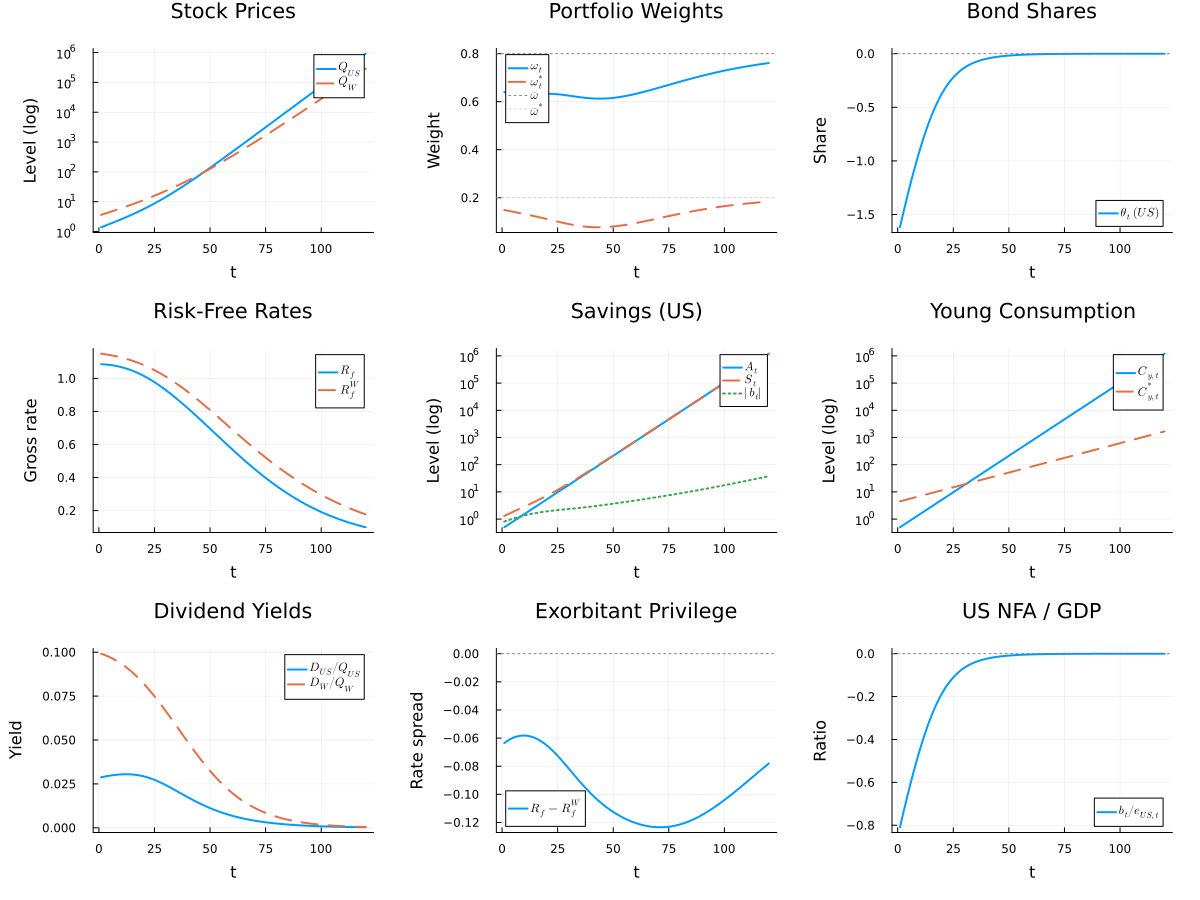

In [6]:
tt = 1:T

Q_US_vec  = [u_path[t].Q_US for t in tt]
Q_W_vec   = [u_path[t].Q_W  for t in tt]
ω_vec     = [u_path[t].ω for t in tt]
ωs_vec    = [u_path[t].ω_star for t in tt]
θ_vec     = [u_path[t].θ for t in tt]
θUs_vec   = [u_path[t].θ_US_star for t in tt]
Rf_vec    = [u_path[t].R_f for t in tt]
RfW_vec   = [u_path[t].R_f_W for t in tt]
S_vec     = [u_path[t].S for t in tt]
Ss_vec    = [u_path[t].S_star for t in tt]
A_vec     = [u_path[t].A for t in tt]
As_vec    = [u_path[t].A_star for t in tt]
Cy_vec    = [u_path[t].C_y for t in tt]
Cys_vec   = [u_path[t].C_y_star for t in tt]
b_vec     = [u_path[t].b for t in tt]
bUs_vec   = [u_path[t].b_US_star for t in tt]

# ── Panel 1: Stock Prices ──
pl1 = plot(tt, Q_US_vec, label=L"Q_{US}", lw=2, yscale=:log10,
           title="Stock Prices", xlabel="t", ylabel="Level (log)")
plot!(pl1, tt, Q_W_vec, label=L"Q_W", lw=2, ls=:dash)

# ── Panel 2: Portfolio Weights ──
pl2 = plot(tt, ω_vec, label=L"\omega_t", lw=2,
           title="Portfolio Weights", xlabel="t", ylabel="Weight")
plot!(pl2, tt, ωs_vec, label=L"\omega^*_t", lw=2, ls=:dash)
hline!(pl2, [p.ω̄], ls=:dot, lc=:gray, label=L"\bar{\omega}")
hline!(pl2, [p.ω̄_star], ls=:dot, lc=:lightgray, label=L"\bar{\omega}^*")

# ── Panel 3: Bond Shares ──
pl3 = plot(tt, θ_vec, label=L"\theta_t\ (US)", lw=2,
           title="Bond Shares", xlabel="t", ylabel="Share")
hline!(pl3, [0.0], ls=:dot, lc=:gray, label="")

# ── Panel 4: Risk-Free Rates ──
pl4 = plot(tt, Rf_vec, label=L"R_f", lw=2,
           title="Risk-Free Rates", xlabel="t", ylabel="Gross rate")
plot!(pl4, tt, RfW_vec, label=L"R^W_f", lw=2, ls=:dash)

# ── Panel 5: Saving Decomposition ──
pl5 = plot(tt, A_vec, label=L"A_t", lw=2, yscale=:log10,
           title="Savings (US)", xlabel="t", ylabel="Level (log)")
plot!(pl5, tt, S_vec, label=L"S_t", lw=2, ls=:dash)
plot!(pl5, tt, abs.(b_vec), label=L"|b_t|", lw=2, ls=:dot)

# ── Panel 6: Young-Age Consumption ──
pl6 = plot(tt, Cy_vec, label=L"C_{y,t}", lw=2, yscale=:log10,
           title="Young Consumption", xlabel="t", ylabel="Level (log)")
plot!(pl6, tt, Cys_vec, label=L"C^*_{y,t}", lw=2, ls=:dash)

# ── Panel 7: Dividend-to-Price Ratios ──
DQ_US = paths.D_US[1:T] ./ Q_US_vec
DQ_W  = paths.D_W[1:T]  ./ Q_W_vec
pl7 = plot(tt, DQ_US, label=L"D_{US}/Q_{US}", lw=2,
           title="Dividend Yields", xlabel="t", ylabel="Yield")
plot!(pl7, tt, DQ_W, label=L"D_W/Q_W", lw=2, ls=:dash)

# ── Panel 8: Exorbitant Privilege ──
ep_vec = Rf_vec .- RfW_vec
pl8 = plot(tt, ep_vec, label=L"R_f - R^W_f", lw=2,
           title="Exorbitant Privilege", xlabel="t", ylabel="Rate spread")
hline!(pl8, [0.0], ls=:dot, lc=:gray, label="")

# ── Panel 9: US Net Foreign Asset Position ──
nfa_ratio = b_vec ./ paths.e_US[1:T]
pl9 = plot(tt, nfa_ratio, label=L"b_t / e_{US,t}", lw=2,
           title="US NFA / GDP", xlabel="t", ylabel="Ratio")
hline!(pl9, [0.0], ls=:dot, lc=:gray, label="")

plot(pl1, pl2, pl3, pl4, pl5, pl6, pl7, pl8, pl9,
     layout=(3,3), size=(1200, 900), margin=5Plots.mm)

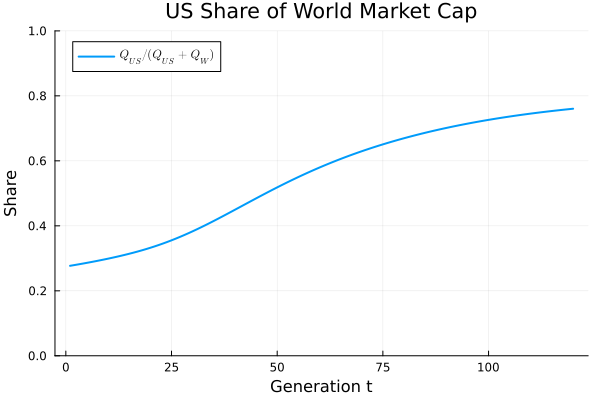

In [7]:
# ── US share of world market cap ──
us_share = Q_US_vec ./ (Q_US_vec .+ Q_W_vec)

plot(tt, us_share, lw=2, label=L"Q_{US}/(Q_{US}+Q_W)",
     xlabel="Generation t", ylabel="Share",
     title="US Share of World Market Cap",
     ylims=(0, 1))

## Summary

- The 6-equation system is solved by backward induction on an extended all-u path with an asymptotic-u successor, then the scratch buffer is trimmed from the reported path.
- All market-clearing conditions (stock, bond, goods from V7) are verified to hold to machine precision.
- $\theta_t \le 0$ (US borrows) and $\theta^*_{US,t} > 0$ (RoW holds US bonds) throughout, consistent with the convenience yield $\chi > 0$ (Lemma 4, V7).
- Phase 1 balanced states incorporate Assumption 7 (V7) switch-date scaling: $\lambda_e \rho^t$ and $\lambda_D \rho_D^t$.
- The exorbitant privilege ($R^W_f > R_f$) is positive — the US borrows at a lower rate.
- The US dividend yield $D_{US}/Q_{US}$ declines over time, suggesting a growing bubble component.

**Next**: Notebook 04 computes the bubble diagnostics (Theorem 1 / Corollary 1, V7).